# Impact of PSF on HSC dwarf surface brightness profiles
### First rough look using a single galaxy

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from dwarfs.photometry import photometry as phot
from dwarfs.photometry import utils

### Building a rough model of a real dwarf

In [2]:
# Read in the masked image
imarr = fits.getdata('masked.fits')

# Convert it to a masked array
maskarr = np.ma.masked_array(imarr, mask=(imarr == -999))

In [3]:
# Make an initial estimate of the dwarf's isophotes, without fitting
prof = phot.Profile(maskarr)

# Estimating galaxy center
halfBoxWid = 20
x0, y0 = prof.initializeCenter(halfBoxWid)

# Fitting isophotes
ellipse = prof.initializeEllipse(x0=x0, y0=y0, sma=20, pa=0, eps=0.5)
isoList = prof.fitEllipses(ellipse)  # Free parameters

# Get orientation from outskirts
want = isoList.sma > 50
pa = np.mean(isoList.pa[want])
eps = np.mean(isoList.eps[want])

In [4]:
# Redo fit using fixed parameters from outskirts
ellipse = prof.initializeEllipse(x0=x0, y0=y0, sma=20, pa=pa, eps=eps)
isoList = prof.fitEllipses(ellipse, maxsma=isoList.sma[-1], maxrit=1, step=3, linear=True)

In [5]:
# Derive total magnitude, for model
magZp = 27
pxScale = 0.17

isoTab = prof.toTable(isoList)
dervals = phot.DerivedValues(isoTab, magZp=magZp, pxScale=pxScale)

sma, cog = dervals.curveOfGrowth(sky=0)
totmag = dervals.totalMagnitude(sma, cog)

/home/awatkins/Science/HSC_Dwarfs/hsc_dwarfs/dwarfs/photometry/utils.py:72: RuntimeWarning: divide by zero encountered in double_scalars
  dydx[0] = y[0] / x[0]  # Replace first value with ratio of initial points


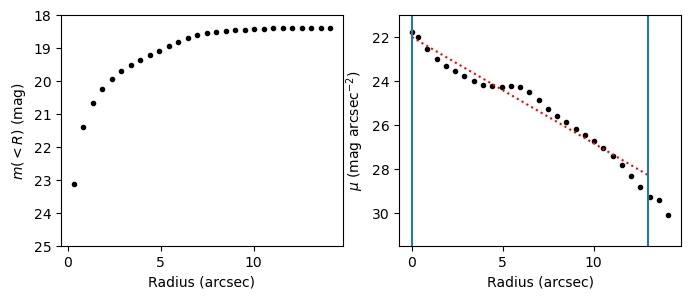

In [6]:
# Curve of growth and surface brightness profile
rad = isoList.sma * pxScale
mag = -2.5*np.log10(isoList.tflux_e) + magZp
sb = -2.5*np.log10(isoList.intens) + magZp + 2.5*np.log10(pxScale**2)

# Fit exponential to everything, plot in red
want = (rad >= 0) & (rad <= 13)
fit = np.polyfit(rad[want], sb[want], 1)
dumx = np.arange(0, 13.1, 0.1)
dumy = fit[0]*dumx + fit[1]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].plot(rad, mag, 'k.')
ax[0].set_xlabel('Radius (arcsec)')
ax[0].set_ylabel(r'$m(<R)$ (mag)')
ax[0].set_ylim([25, 18])

ax[1].plot(rad, sb, 'k.')
ax[1].plot(dumx, dumy, 'r:')
ax[1].set_xlabel('Radius (arcsec)')
ax[1].set_ylabel(r'$\mu$ (mag arcsec$^{-2}$)')
ax[1].set_ylim([31.5, 21])
ax[1].axvline(0)
ax[1].axvline(13)

In [7]:
# Convert best-fit exponential profile to linear parameters
i0 = 10**(-0.4*(fit[1] - magZp))  # HSC units/arcsec^2
h = 2.5/(np.log(10)*fit[0])  # arcsec
flux = 10**(-0.4*(totmag - magZp))  # HSC units

In [8]:
# Now create a 2D model of this best-fit exponential using GalSim, assuming no PSF first (unconvolved)
import galsim

exp = galsim.Exponential(scale_radius=h)
exp = exp.withFlux(flux)
bounds = galsim.BoundsI(1, 501, 1, 501)  # Ensures center is at an integer pixel
unConv = exp.drawImage(scale=pxScale, bounds=bounds)

In [9]:
# Now make a convolved version, using Mireia's PSF as the convolution kernel
from scipy.signal import fftconvolve

psf = fits.getdata("psf_i-band.fits")
exp = galsim.Exponential(scale_radius=h)
exp = exp.withFlux(flux)
bounds = galsim.BoundsI(1, 501, 1, 501)
conv = exp.drawImage(scale=pxScale, bounds=bounds)
conv = fftconvolve(conv.array, psf, mode="same")

(200.0, 300.0)

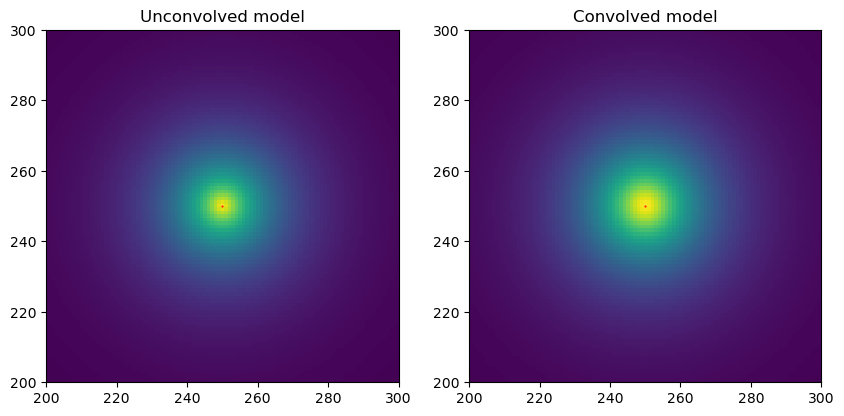

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title("Unconvolved model")
ax[0].imshow(unConv.array)
ax[0].plot(250, 250, "r.", markersize=1.0)  # Marking the center pixel in red
ax[0].set_xlim([200, 300])
ax[0].set_ylim([200, 300])

ax[1].set_title("Convolved model")
ax[1].imshow(conv)
ax[1].plot(250, 250, "r.", markersize=1.0)
ax[1].set_xlim([200, 300])
ax[1].set_ylim([200, 300])

### Deriving the aperture correction to the profile for PSF light scattering

In [18]:
# Measure surface brightness profiles of both models using same fixed isophotal parameters
maxsma = isoList.sma[-1]+3  # Using previous fit extent, so radius array is the same
x0 = 250  # Model stamp center
y0 = 250  # Model stamp center
sma = 20  # For initialization
pa = 0  # Face-on
eps = 0  # Face-on

# Unconvolved profile
profUnConv = phot.Profile(unConv.array)
ellipseUc = profUnConv.initializeEllipse(x0=x0, y0=y0, sma=20, pa=pa, eps=eps)
isoListUc = profUnConv.fitEllipses(ellipseUc, maxsma=maxsma, maxrit=1, step=3, linear=True)

# Convolved profile
profConv = phot.Profile(conv)
ellipseC = profConv.initializeEllipse(x0=x0, y0=y0, sma=20, pa=pa, eps=eps)
isoListC = profConv.fitEllipses(ellipseC, maxsma=maxsma, maxrit=1, step=3, linear=True)

Text(0.5, 0, 'R (arcsec)')

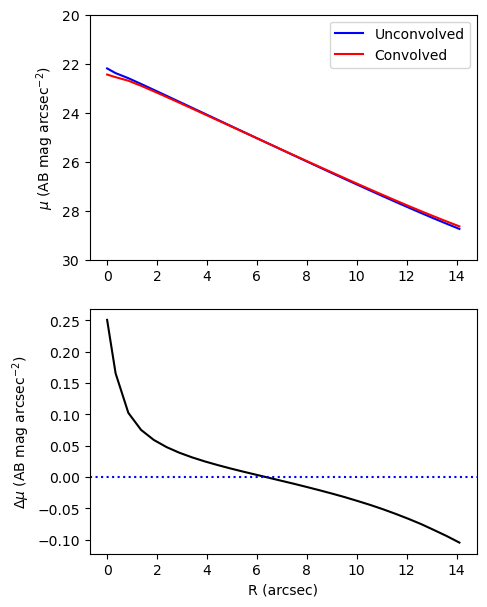

In [19]:
# Overplot the profiles
radUc = isoListUc.sma * pxScale
sbUc = -2.5*np.log10(isoListUc.intens) + magZp + 2.5*np.log10(pxScale**2)
sbC = -2.5*np.log10(isoListC.intens) + magZp + 2.5*np.log10(pxScale**2)

fig, ax = plt.subplots(2, 1, figsize=(5, 7))
ax[0].plot(radUc, sbUc, "b", label="Unconvolved")
ax[0].plot(radUc, sbC, "r", label="Convolved")
ax[0].legend()
ax[0].set_ylim([30, 20])
ax[0].set_ylabel(r"$\mu$ (AB mag arcsec$^{-2}$)")

# And the difference between them, in magnitudes, just to have a look
ax[1].plot(radUc, sbC - sbUc, "k")
ax[1].axhline(0, c="b", linestyle=":")
ax[1].set_ylabel(r"$\Delta \mu$ (AB mag arcsec$^{-2}$)")
ax[1].set_xlabel("R (arcsec)")

In [21]:
# Now derive the actual aperture correction factor following Watkins et al. (2022)
iUc = isoListUc.intens  # Unconvolved
iC = isoListC.intens  # Convolved

# This here: multiply the original profile by the ratio of the unconvolved to the convolved model profiles
iCorr = isoList.intens * (iUc/iC)  # In linear units
sbCorr = -2.5*np.log10(iCorr) + magZp + 2.5*np.log10(pxScale**2)

Text(0.5, 0, 'Radius (arcsec)')

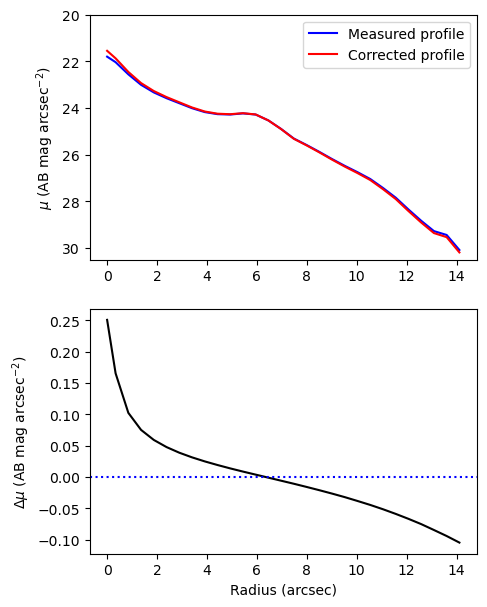

In [27]:
# Overplot profiles
fig, ax = plt.subplots(2, 1, figsize=(5, 7))
ax[0].plot(rad, sb, "b", label="Measured profile")
ax[0].plot(rad, sbCorr, "r", label="Corrected profile")
ax[0].legend()
ax[0].set_ylim([30.5, 20])
ax[0].set_ylabel(r"$\mu$ (AB mag arcsec$^{-2}$)")

# And the difference between them: it's the same as the difference between the two model profiles, as expected
ax[1].plot(rad, sb - sbCorr, "k")
ax[1].axhline(0, c="b", linestyle=":")
ax[1].set_ylabel(r"$\Delta \mu$ (AB mag arcsec$^{-2}$)")
ax[1].set_xlabel("Radius (arcsec)")

PSF scattering moves light from the center out, and from the outskirts in.  The center is brighter than the outskirts, so the correction for the core is to increase its brightness, and the correction in the outskirts is to decrease the brightness.

This basic experiment implies this might be a correction worth doing for the HSC dwarf sample, even though the effect isn't all that huge.